# 02. Baseline e Modelos Clássicos (multi-horizonte h = 1, 2, 3)

As famílias clássicas de séries temporais (Naïve, Seasonal Naïve, SES, Holt, Holt-Winters, ARIMA e SARIMA) são ajustadas e avaliadas nos 3 horizontes de interesse (1, 2 e 3 dias úteis à frente), usando o esquema de validação walk-forward com janela expansiva definido no notebook 01.

Em cada uma das 17 origens de validação são usados apenas os dados conhecidos até aquele dia, o modelo é ajustado ou reajustado, previsões são geradas para os próximos 3 dias e comparadas com o valor real, sem nunca usar dado futuro.

In [1]:
import sys
sys.path.append("../src")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import itertools

import case_utils as cu

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})


In [2]:
train, test = cu.load_processed("../data/processed")
full = cu.make_full_series(train, test)
full_dates = full["Date"].values
full_values = full["Close"].values

origins = cu.walkforward_origins(len(train), len(test), max_h=max(cu.HORIZONS))
print(f"{len(origins)} origens de validação | horizontes: {cu.HORIZONS}")


17 origens de validação | horizontes: (1, 2, 3)


## Naïve e Seasonal Naïve

- Naïve: repete o último valor conhecido para todos os horizontes (h=1, 2 e 3 recebem a mesma previsão).
- Seasonal Naïve (m=5): repete o valor observado `m` dias úteis atrás, usando o valor da mesma posição do ciclo semanal de 5 dias.

In [3]:
rows = []
m = 5

for origin in origins:
    origin_date = full_dates[origin]
    last_value = full_values[origin]

    for h in cu.HORIZONS:
        cu.append_predictions(rows, origin_date, full_dates, full_values, origin, h, "naive", last_value)

        idx_ref = (origin + h) - m
        cu.append_predictions(rows, origin_date, full_dates, full_values, origin, h, "seasonal_naive", full_values[idx_ref])

results_baseline = pd.DataFrame(rows)
print(results_baseline.shape)
results_baseline.head(8)


(102, 6)


,origin_date,target_date,horizon,model,y_true,y_pred
0,2018-05-25,2018-05-28,1,naive,16.910000,19.799999
1,2018-05-25,2018-05-28,1,seasonal_naive,16.910000,25.049999
2,2018-05-25,2018-05-29,2,naive,19.299999,19.799999
3,2018-05-25,2018-05-29,2,seasonal_naive,19.299999,24.709999
4,2018-05-25,2018-05-30,3,naive,18.980000,19.799999
5,2018-05-25,2018-05-30,3,seasonal_naive,18.980000,23.270000
6,2018-05-28,2018-05-29,1,naive,19.299999,16.910000
7,2018-05-28,2018-05-29,1,seasonal_naive,19.299999,24.709999


## SES, Holt e Holt-Winters

Cada modelo é reajustado em cada origem, com janela expansiva formada pelo treino completo mais os dias de teste já revelados, e `forecast(3)` é usado para obter h=1, 2 e 3 de uma só vez.

In [4]:
rows_suav = []

for origin in origins:
    origin_date = full_dates[origin]
    history = pd.Series(full_values[: origin + 1])
    history.index = pd.RangeIndex(len(history))

    ses = SimpleExpSmoothing(history, initialization_method="estimated").fit(optimized=True)
    ses_fc = ses.forecast(3)

    holt = Holt(history, initialization_method="estimated", damped_trend=True).fit(optimized=True)
    holt_fc = holt.forecast(3)

    hw = ExponentialSmoothing(history, trend="add", damped_trend=True, seasonal="add", seasonal_periods=5,
                               initialization_method="estimated").fit(optimized=True)
    hw_fc = hw.forecast(3)

    for i, h in enumerate(cu.HORIZONS):
        cu.append_predictions(rows_suav, origin_date, full_dates, full_values, origin, h, "ses", ses_fc.iloc[i])
        cu.append_predictions(rows_suav, origin_date, full_dates, full_values, origin, h, "holt", holt_fc.iloc[i])
        cu.append_predictions(rows_suav, origin_date, full_dates, full_values, origin, h, "holt_winters", hw_fc.iloc[i])

results_suavizacao = pd.DataFrame(rows_suav)
print(len(origins), "origens x 3 modelos x 3 horizontes =", len(results_suavizacao), "linhas")


17 origens x 3 modelos x 3 horizontes = 153 linhas


## ARIMA e SARIMA

A ordem (p, d, q) é escolhida uma única vez por AIC no treino completo, já que escolher a estrutura a cada uma das 17 origens seria caro e instável. O que é reajustado em cada origem são os parâmetros do modelo com essa ordem fixa, prática padrão em produção: a estrutura muda pouco no curto prazo, os coeficientes são recalibrados com o dado novo.

In [5]:
y_train_only = pd.Series(train["Close"].values)
y_train_only.index = pd.RangeIndex(len(y_train_only))

best_aic, best_order = np.inf, None
for p, d, q in itertools.product(range(0, 4), [1], range(0, 4)):
    try:
        m_fit = ARIMA(y_train_only, order=(p, d, q)).fit()
        if m_fit.aic < best_aic:
            best_aic, best_order = m_fit.aic, (p, d, q)
    except Exception:
        continue
print("Melhor ordem ARIMA (por AIC, no treino completo):", best_order, f"AIC={best_aic:.2f}")

best_saic, best_sorder = np.inf, None
for P, D, Q in itertools.product(range(0, 2), [0, 1], range(0, 2)):
    try:
        m_fit = ARIMA(y_train_only, order=best_order, seasonal_order=(P, D, Q, 5)).fit()
        if m_fit.aic < best_saic:
            best_saic, best_sorder = m_fit.aic, (P, D, Q, 5)
    except Exception:
        continue
print("Melhor ordem sazonal SARIMA (m=5):", best_sorder, f"AIC={best_saic:.2f}")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Melhor ordem ARIMA (por AIC, no treino completo): (2, 1, 2) AIC=1600.34


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


Melhor ordem sazonal SARIMA (m=5): (0, 0, 0, 5) AIC=1600.34


In [6]:
rows_arima = []

for origin in origins:
    origin_date = full_dates[origin]
    history = pd.Series(full_values[: origin + 1])
    history.index = pd.RangeIndex(len(history))

    arima_fit = ARIMA(history, order=best_order).fit()
    arima_fc = arima_fit.forecast(3)

    sarima_fit = ARIMA(history, order=best_order, seasonal_order=best_sorder).fit()
    sarima_fc = sarima_fit.forecast(3)

    for i, h in enumerate(cu.HORIZONS):
        cu.append_predictions(rows_arima, origin_date, full_dates, full_values, origin, h, "arima", arima_fc.iloc[i])
        cu.append_predictions(rows_arima, origin_date, full_dates, full_values, origin, h, "sarima", sarima_fc.iloc[i])

results_arima = pd.DataFrame(rows_arima)
print("ARIMA e SARIMA ajustados em", len(origins), "origens.")


ARIMA e SARIMA ajustados em 17 origens.


## Consolidação dos resultados clássicos

In [7]:
results_classicos = pd.concat([results_baseline, results_suavizacao, results_arima], ignore_index=True)
results_classicos.to_csv("../results/predictions_classicos.csv", index=False)

metrics_classicos = cu.summarize_by_horizon(results_classicos)
metrics_classicos.to_csv("../results/metrics_classicos.csv", index=False)

metrics_classicos.pivot(index="model", columns="horizon", values="MAPE").round(2)


horizon,1,2,3
model,,,
arima,5.23,5.49,4.94
holt,5.11,5.12,4.41
holt_winters,5.33,5.57,5.02
naive,5.25,5.42,5.22
sarima,5.23,5.49,4.94
seasonal_naive,13.55,10.72,9.13
ses,5.24,5.38,5.18


### Erro (MAPE) por horizonte, modelos clássicos

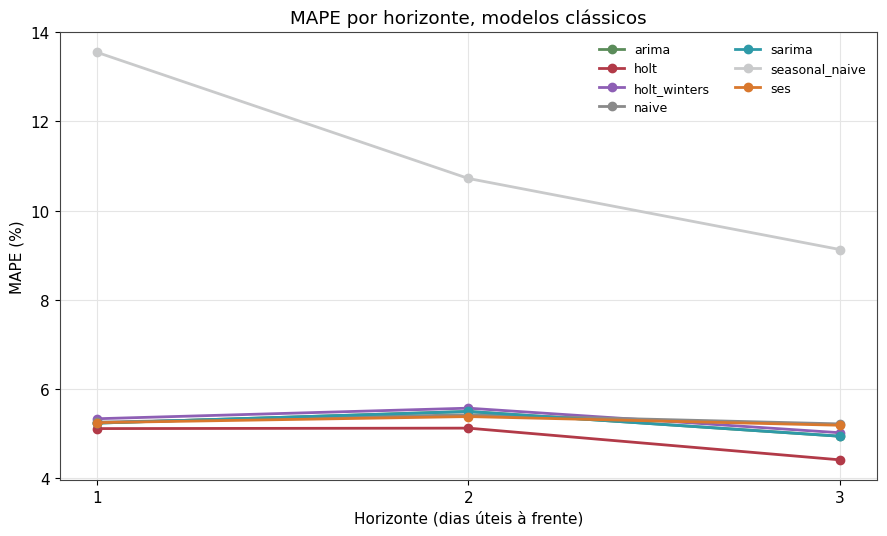

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for model, g in metrics_classicos.groupby("model"):
    g = g.sort_values("horizon")
    ax.plot(g["horizon"], g["MAPE"], marker="o", color=cu.PALETTE.get(model, "#666666"), label=model, linewidth=2)
ax.set_xticks(cu.HORIZONS)
ax.set_xlabel("Horizonte (dias úteis à frente)")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE por horizonte, modelos clássicos")
ax.legend(frameon=False, ncol=2, fontsize=9)
fig.tight_layout()
plt.show()


Leitura: a intuição de livro-texto diria que o erro deveria crescer monotonicamente com o horizonte, já que mais dias à frente significam mais incerteza acumulada. Aqui isso não se confirma com força para os modelos clássicos: MAPE e RMSE ficam bem próximos entre h=1, h=2 e h=3, e alguns modelos (Holt, ARIMA) até melhoram ligeiramente em h=3.

Isso acontece porque, nesse período específico de teste, o preço segue uma tendência de queda razoavelmente consistente. Modelos com componente de tendência (Holt, ARIMA com d=1) acompanham essa queda tanto em h=1 quanto em h=3, e o Naïve puro erra de forma parecida em todos os horizontes porque a variação dia a dia (retorno) é pequena e ruidosa perto do último valor conhecido. Com apenas 17 origens de validação, também há bastante variância nessa comparação. O notebook `04_comparacao_final` volta a esse ponto ao juntar os resultados de Machine Learning do notebook `03_machine_learning` e verificar se o padrão se mantém.